> **Data required:** This notebook uses InSight HP³ data from Spohn et al. (2024). 
> If you haven't already, download the datasets from [FigShare](https://doi.org/10.6084/m9.figshare.25099754) 
> and place them in `resources/data/`. See [`resources/data/README.md`](../resources/data/README.md) for details.

This PINN will be used to calculate the temperature of points at the r_max boundaries of the perturbance PINN

# 1D Forward PINN — Far-Field Boundary Condition Generator

Every boundary condition used so far has come from one of two places: raw instrument data (RAD, TEM-A) or a fixed analytical formula. The 2D axisymmetric notebook needs a third kind — a boundary condition at $r = r_\text{max}$ that describes the **undisturbed soil temperature** at any depth and time, as if the mole were not there. No closed-form solution exists for this. Instead, this notebook trains a dedicated 1D PINN whose sole purpose is to become that boundary condition.

The idea is simple: train a network to solve the 1D heat equation driven only by the RAD surface forcing, with no mole data and no radial geometry. The result is a smooth, differentiable function $T_\text{1D}(z, t)$ that the 2D PINN can query at $r = r_\text{max}$ — a frozen neural network standing in for an analytical far-field solution.

---

## What is Different From Previous 1D Notebooks

This is a **forward problem only** — $\kappa$ is fixed and not learned. The network is not trying to recover a physical parameter. It is trying to produce the most accurate possible representation of the undisturbed soil temperature field, which will then be handed off as a Dirichlet boundary condition to the 2D model.

Three deliberate choices make this representation more reliable:

**1. No TEM-A data.** The mole temperature is intentionally excluded. This PINN must represent soil with no mole present — including TEM-A would corrupt the far-field with the very perturbation we are trying to isolate.

**2. Depth-biased collocation sampling.** Physics points are sampled as $x = u^3 \cdot z_\text{max}$ where $u \sim \text{Uniform}[0,1]$. This clusters points near the surface, where the diurnal signal is strongest and the temperature gradient is steepest. Uniform sampling would waste most points in the deep isothermal region where the residual is trivially small.

**3. Periodicity loss.** A dedicated loss term enforces $T(z, 0) = T(z, t_\text{sol})$ at 100 depth points — the temperature profile at the start and end of the sol must match. This encodes the physical fact that the diurnal cycle repeats, anchoring the network to a self-consistent periodic solution rather than one that drifts between the two endpoints.

---

## Loss Structure

$$\mathcal{L} = 10 \cdot \mathcal{L}_\text{BC} + \mathcal{L}_\text{physics} + 10 \cdot \mathcal{L}_\text{periodic}$$

**Boundary conditions:** RAD surface data at $z = 0$, fixed mean temperature at $z = z_\text{max}$

**Physics residual:** 1D heat equation evaluated at 20,000 depth-biased collocation points, resampled every 5000 iterations to prevent the network from overfitting to a fixed point cloud

**Periodicity:** $T(z, 0) = T(z, t_\text{sol})$ enforced across 100 uniformly spaced depth points

The trained checkpoint is saved and loaded directly by the 2D PINN as a frozen forward-pass boundary condition at $r = r_\text{max}$.

In [ ]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import openpyxl
import optax

import jax.numpy as jnp

import copy

# Problem parameters
kappa = 3.93e-8       # thermal diffusivity we will try with different values
depth = 0.4           # domain depth [m]
sol_seconds = 88775.244  # one sol [s]

avg_bottom_temp = 225.6  # average bottom temperature (K)

n_points = 20000

# RAD Sol 511   = surface temperature from radiometer (Spohn's proxy for sol 1202)
wb_diurnal = openpyxl.load_workbook(
    '../../resources/data/Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    # Column index 4 = 'LTST converted' (hours)
    # Column index 5 = 'FOV 2 Temperature converted' (Kelvin)
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass

# Sort surface data by LTST (it may not be in order)
sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

# Conversion from hours to seconds for the time points. Make sure it is mapped correctly to the Mars sol time (0-88775.244 seconds)
ltst_surf = [t * sol_seconds / 24 for t in ltst_surf]


# 1. Boundary Condition points (552 points each edge as we have 552 time points in the surface data)
n_surface = len(ltst_surf)  # Should be 552

# Surface boundary (x=0):
t_bc_surface = jnp.array(ltst_surf).reshape(-1, 1)  # (552, 1)
x_bc_surface = jnp.zeros((n_surface, 1))  # (552, 1)

u_bc_surface = jnp.array(temp_surf).reshape(-1, 1)  # (552, 1)

# Bottom boundary (x=depth):
t_bc_bottom = jnp.linspace(0, sol_seconds, n_surface).reshape(-1, 1)  # (552, 1)
x_bc_bottom = jnp.ones((n_surface, 1)) * depth

u_bc_bottom = jnp.ones((n_surface, 1)) * avg_bottom_temp  # (552, 1)

# Combine them:
t_bc = jnp.concatenate([t_bc_surface, t_bc_bottom])
x_bc = jnp.concatenate([x_bc_surface, x_bc_bottom])
u_bc = jnp.concatenate([u_bc_surface, u_bc_bottom])


# Normalise the data so the network only sees values of order 1. This helps with training stability and convergence. We will need to un-normalise the predictions later to compare with the original data.

# Normalisation parameters
t_min, t_max = 0.0, sol_seconds
x_min, x_max = 0.0, depth
u_min, u_max = 185.0, 300.0  # Based on the range of temperatures in the data

def normalize_t(t): return ( t - t_min) / (t_max - t_min)
def normalize_x(x): return ( x - x_min) / (x_max - x_min)
def normalize_u(u): return ( u - u_min) / (u_max - u_min)

def unnormalize_u(u_norm): return u_norm * (u_max - u_min) + u_min

# Normalize all data
t_bc = normalize_t(t_bc)
x_bc = normalize_x(x_bc)
u_bc = normalize_u(u_bc)


#Normalize kappa as well (since it appears in the physics residual)
kappa_eff = kappa * (t_max - t_min) / ((x_max - x_min)**2)  # Effective diffusivity in normalized space

# 2. Physics collocation points (100 * 100 = 10,000 points).
key = random.PRNGKey(0)

def sample_collocation_points(key, n_points):

  p = 3

  key1, key2 = random.split(key)
  t_physics = random.uniform(key1, (n_points, 1), minval=0, maxval=sol_seconds)

  u = random.uniform(key2, (n_points, 1))   # uniform on [0, 1]
  x_physics = (u ** p) * depth               # biased toward 0, in [0, depth]

  t_physics = normalize_t(t_physics)
  x_physics = normalize_x(x_physics)

  return t_physics, x_physics


t_physics, x_physics = sample_collocation_points(key, n_points)



# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.

    Args:
        layer_sizes: List of layer sizes, e.g., [2, 32, 32, 32, 1]
                    (input_dim, hidden1, hidden2, hidden3, output_dim)
        key: JAX random key for initialization

    Returns:
        params: List of dictionaries, each containing 'w' and 'b'
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))

    params = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]

        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])

        # Xavier initialization for weights
        params.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })

    return params


def network(params, x):
    """
    Forward pass through the network.

    Args:
        params: List of layer parameters (from init_network_params)
        x: Input array, shape (batch_size, input_dim)

    Returns:
        Output array, shape (batch_size, output_dim)
    """
    # Process all hidden layers (all but last)
    for layer in params[:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)

    # Output layer (no activation)
    final_layer = params[-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']

    return x


# Calculate Residual

def physics_residual_single(params, t_point, x_point, kappa_eff):

    def u(t_val, x_val):
        tx_in = jnp.array([[t_val, x_val]])
        return network(params, tx_in)[0, 0]

    du_dt = grad(u, argnums=0)(t_point, x_point)

    d2u_dx2 = grad(grad(u, argnums = 1), argnums=1)(t_point, x_point)

    return du_dt / kappa_eff - d2u_dx2


# Vectorize to handle all physics points at once
# So vmap will call physics_residual_single 10000 times, once for each (t, x) pair, keeping params and kappa_eff fixed.
physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0, None))


# Initialize network
key = random.PRNGKey(123)
layer_sizes = [2, 64, 64, 64, 64, 1]  # 2 inputs (t, x), 1 output (u)
params = init_network_params(layer_sizes, key)

# Initialize optimizer
learning_rate = 1e-3
schedule = optax.piecewise_constant_schedule(init_value=learning_rate, boundaries_and_scales={60000: 0.1, 120000: 0.01})
optimizer = optax.adam(schedule)
opt_state = optimizer.init(params)


@jit
def update_step(params, opt_state,
                t_bc, x_bc, u_bc, t_physics, x_physics, kappa_eff, tx_start, tx_end):

    def loss_fn(params):

        # 1. Boundary Condition Loss
        tx_bc = jnp.concatenate([t_bc, x_bc], axis=1)
        u_pred_bc = network(params, tx_bc)
        bc_loss = jnp.mean((u_pred_bc - u_bc)**2)

        # 2. Physics Loss
        physics_residuals = physics_residual_batch(params,
                                                t_physics.ravel(), # (10000,) not (10000, 1)
                                                x_physics.ravel(), # (10000,) not (10000, 1)
                                                kappa_eff)
        physics_loss = jnp.mean(physics_residuals**2) # Physics residual is of 10000 points.

        # 3. Periodicity loss — T must be the same at start and end of sol

        periodic_loss = jnp.mean((network(params, tx_start) - network(params, tx_end))**2)

        total = bc_loss * 10 + physics_loss + periodic_loss * 10
        return total, (bc_loss, physics_loss, periodic_loss)


    # Compute loss and gradients
    (loss_val, individual_loss), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)

    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)

    return new_params, new_opt_state, loss_val, individual_loss


# Training parameters
num_iterations = 150000
save_every = 1000  # Save every 150 iterations
print_every = 1000

# Storage for snapshots
snapshots = []
snapshot_iterations = []

# Compute Periodic Loss
x_periodic = jnp.linspace(0, 1, 100).reshape(-1, 1)  # 100 depth points

t_start = jnp.zeros_like(x_periodic)        # t = 0
t_end = jnp.ones_like(x_periodic)            # t = 1 (normalized)

tx_start = jnp.concatenate([t_start, x_periodic], axis=1)
tx_end = jnp.concatenate([t_end, x_periodic], axis=1)

# Training loop
losses = []
losses_bc = []
losses_phys = []
for i in range(num_iterations):
    params, opt_state, loss, individual_loss = update_step(
        params, opt_state,
        t_bc, x_bc, u_bc,
        t_physics, x_physics,
        kappa_eff,
        tx_start, tx_end
    )

    losses.append(loss)
    losses_bc.append(individual_loss[0])
    losses_phys.append(individual_loss[1])

    # Resampling every 5k
    if (i + 1) % 5000 == 0:
        key, subkey = random.split(key)  # advance the key
        t_physics, x_physics = sample_collocation_points(key, n_points)


    # Save snapshot every 150 iterations
    if (i + 1) % save_every == 0:
        # Make a copy of params (important!)
        snapshots.append(copy.deepcopy(params))
        snapshot_iterations.append(i + 1)


    if (i + 1) % print_every == 0:
        print(f"Iteration {i+1}/{num_iterations}, Loss: {loss:.6f}")
        print(f"  BC Loss: {individual_loss[0]:.6f}, Physics Loss: {individual_loss[1]:.6f}")


# Fine tuning with L-BFGS

# import jaxopt

# # Freeze one set of collocation points for L-BFGS
# key, subkey = random.split(key)
# t_phys_lbfgs, x_phys_lbfgs = sample_collocation_points(subkey, 20000)

# # L-BFGS needs a pure scalar loss function — no aux
# def lbfgs_loss(params):
#     tx_bc = jnp.concatenate([t_bc, x_bc], axis=1)
#     u_pred_bc = network(params, tx_bc)
#     bc_loss = jnp.mean((u_pred_bc - u_bc)**2)

#     residuals = physics_residual_batch(
#         params, t_phys_lbfgs.ravel(), x_phys_lbfgs.ravel(), kappa_eff)
#     physics_loss = jnp.mean(residuals**2)

#     tx_start = jnp.concatenate([jnp.zeros_like(x_periodic), x_periodic], axis=1)
#     tx_end = jnp.concatenate([jnp.ones_like(x_periodic), x_periodic], axis=1)
#     periodic_loss = jnp.mean((network(params, tx_start) - network(params, tx_end))**2)

#     return bc_loss * 10 + physics_loss + periodic_loss * 10

# # Run L-BFGS starting from Adam's final params
# solver = jaxopt.LBFGS(fun=lbfgs_loss, maxiter=5000)
# result = solver.run(params)
# params = result.params
# print(f"L-BFGS final loss: {lbfgs_loss(params):.6f}")



import pickle

checkpoint = {
    # Learned parameters
    'params': jax.device_get(params),
    'opt_state': jax.device_get(opt_state),

    # Loss histories
    'losses': [float(l) for l in losses],
    'losses_bc': [float(l) for l in losses_bc],
    'losses_phys': [float(l) for l in losses_phys],

    # Snapshots for animation
    'snapshots': [jax.device_get(s) for s in snapshots],
    'snapshot_iterations': snapshot_iterations,

    # Training config (so you remember what produced this)
    'num_iterations': num_iterations,
    'layer_sizes': layer_sizes,
    'learning_rate': learning_rate,

    'norm': {
        't_min': 0.0, 't_max': 88775.244,
        'x_min': 0.0, 'x_max': 0.4,
        'u_min': 185.0, 'u_max': 300.0,
    },
    'kappa': 3.93e-8,
    'kappa_eff': float(kappa_eff),
}

with open('checkpoints_1D/run_02.pkl', 'wb') as f:
    pickle.dump(checkpoint, f)


Iteration 1000/150000, Loss: 0.620944
  BC Loss: 0.055437, Physics Loss: 0.060340
Iteration 2000/150000, Loss: 0.564257
  BC Loss: 0.054584, Physics Loss: 0.015250
Iteration 3000/150000, Loss: 0.551838
  BC Loss: 0.054051, Physics Loss: 0.009601
Iteration 4000/150000, Loss: 0.544011
  BC Loss: 0.053496, Physics Loss: 0.007760
Iteration 5000/150000, Loss: 0.539077
  BC Loss: 0.052939, Physics Loss: 0.007108
Iteration 6000/150000, Loss: 0.697150
  BC Loss: 0.052360, Physics Loss: 0.168387
Iteration 7000/150000, Loss: 0.531199
  BC Loss: 0.052311, Physics Loss: 0.002742
Iteration 8000/150000, Loss: 0.532918
  BC Loss: 0.052018, Physics Loss: 0.006566
Iteration 9000/150000, Loss: 0.548852
  BC Loss: 0.051464, Physics Loss: 0.026494
Iteration 10000/150000, Loss: 0.523347
  BC Loss: 0.051135, Physics Loss: 0.003472
Iteration 11000/150000, Loss: 0.517027
  BC Loss: 0.050373, Physics Loss: 0.003204
Iteration 12000/150000, Loss: 0.567980
  BC Loss: 0.050966, Physics Loss: 0.052020
Iteration 130

Plots

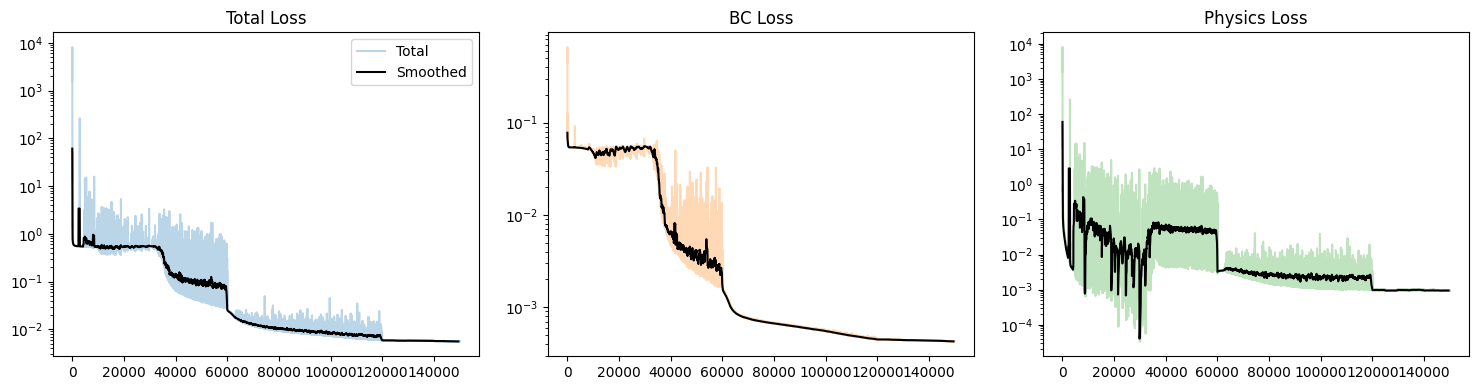

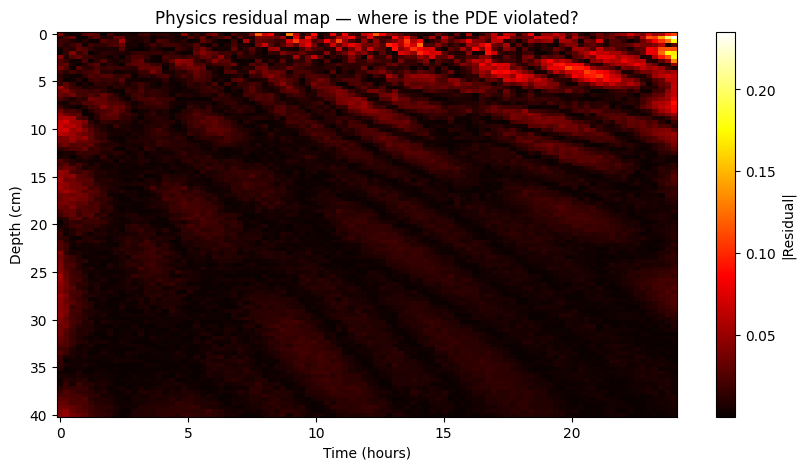

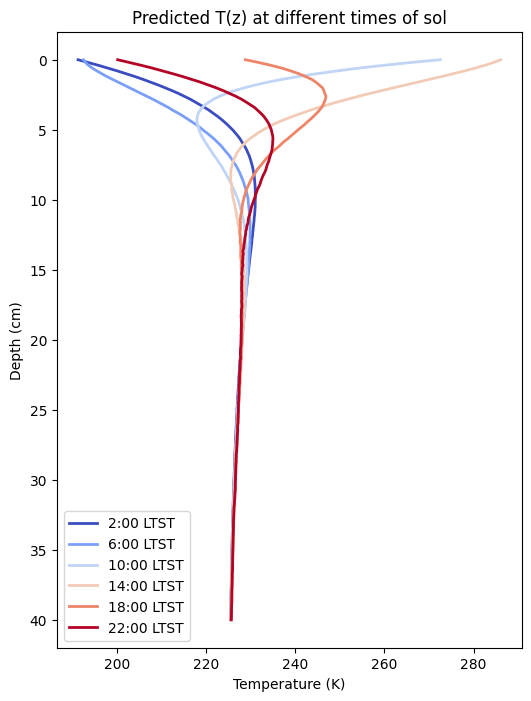

In [24]:
# ============================================
# DIAGNOSTIC 1: Loss curves (log scale)
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].semilogy(losses, alpha=0.3, label='Total')
axes[0].semilogy(np.convolve(losses, np.ones(500)/500, mode='valid'), 'k', label='Smoothed')
axes[0].set_title('Total Loss'); axes[0].legend()

axes[1].semilogy(losses_bc, alpha=0.3, color='tab:orange')
axes[1].semilogy(np.convolve(losses_bc, np.ones(500)/500, mode='valid'), 'k')
axes[1].set_title('BC Loss')

axes[2].semilogy(losses_phys, alpha=0.3, color='tab:green')
axes[2].semilogy(np.convolve(losses_phys, np.ones(500)/500, mode='valid'), 'k')
axes[2].set_title('Physics Loss')

plt.tight_layout(); plt.show()

# ============================================
# DIAGNOSTIC 2: Where is the residual highest?
# This is the most important plot — it shows
# WHERE in the (t, z) domain the PDE is violated
# ============================================
n_grid = 100
t_grid = jnp.linspace(0, 1, n_grid)
x_grid = jnp.linspace(0, 1, n_grid)
T_mesh, X_mesh = jnp.meshgrid(t_grid, x_grid)

t_flat = T_mesh.ravel()
x_flat = X_mesh.ravel()

# Compute residual at every grid point
residuals = physics_residual_batch(params, t_flat, x_flat, kappa_eff)
R = residuals.reshape(n_grid, n_grid)

fig, ax = plt.subplots(figsize=(10, 5))
# x_grid is normalized [0,1], convert back to cm for readability
c = ax.pcolormesh(t_grid * 24,          # time in hours
                  x_grid * depth * 100,  # depth in cm
                  jnp.abs(R),
                  cmap='hot', shading='auto')
plt.colorbar(c, label='|Residual|')
ax.set_xlabel('Time (hours)')
ax.set_ylabel('Depth (cm)')
ax.set_title('Physics residual map — where is the PDE violated?')
ax.invert_yaxis()  # surface at top
plt.show()

# ============================================
# DIAGNOSTIC 3: Temperature profiles at key times
# Shows if the thermal wave shape makes physical sense
# ============================================
fig, ax = plt.subplots(figsize=(6, 8))
x_plot = jnp.linspace(0, 1, 200).reshape(-1, 1)  # normalized depth

hours_to_plot = [2, 6, 10, 14, 18, 22]  # spread across the sol
colors = plt.cm.coolwarm(np.linspace(0, 1, len(hours_to_plot)))

for h, color in zip(hours_to_plot, colors):
    t_norm = h / 24.0  # convert hours to normalized time
    t_col = jnp.ones_like(x_plot) * t_norm
    tx_in = jnp.concatenate([t_col, x_plot], axis=1)

    T_pred = unnormalize_u(network(params, tx_in))

    ax.plot(T_pred, x_plot * depth * 100, color=color,
            linewidth=2, label=f'{h}:00 LTST')

ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Depth (cm)')
ax.set_title('Predicted T(z) at different times of sol')
ax.invert_yaxis()
ax.legend()
plt.show()

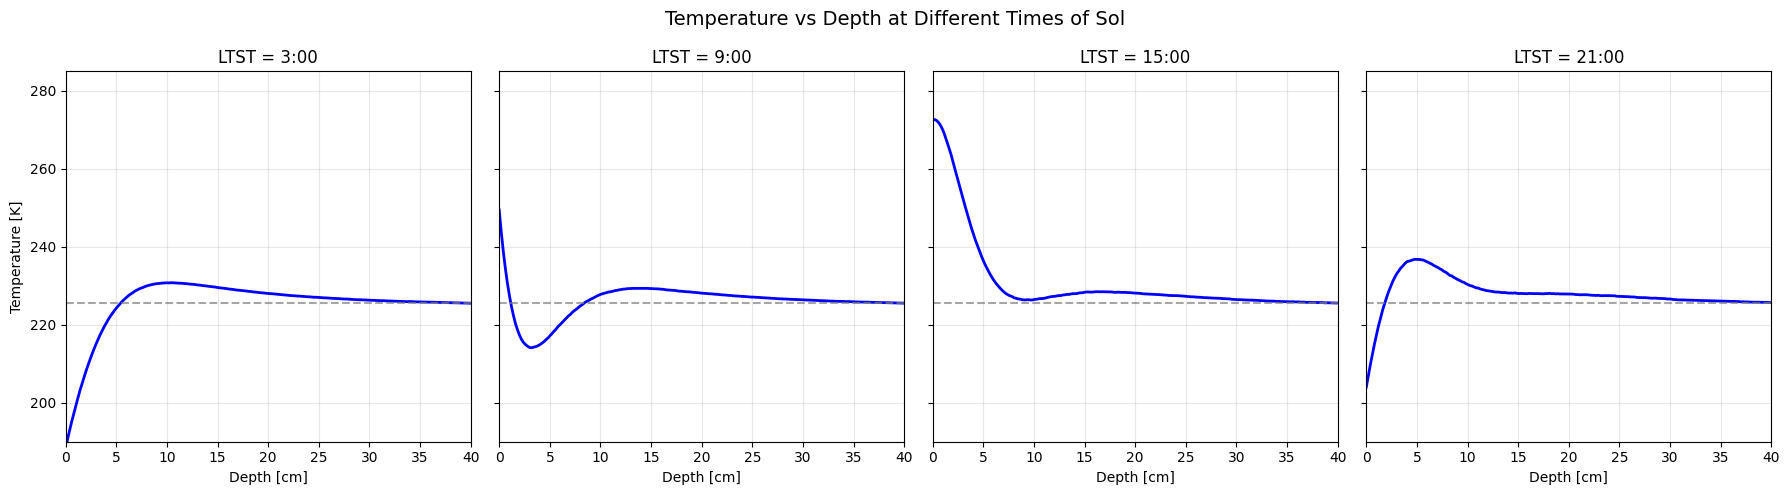

In [25]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
fig.suptitle('Temperature vs Depth at Different Times of Sol', fontsize=14)

hours_to_plot = [3, 9, 15, 21]
x_plot = jnp.linspace(0, 1, 200).reshape(-1, 1)  # normalized depth
depth_cm = x_plot.ravel() * depth * 100            # for plotting in cm

for ax, h in zip(axes, hours_to_plot):
    t_norm = h / 24.0
    t_col = jnp.ones_like(x_plot) * t_norm
    tx_in = jnp.concatenate([t_col, x_plot], axis=1)

    T_pred = unnormalize_u(network(params, tx_in)).ravel()

    ax.plot(depth_cm, T_pred, 'b', linewidth=2)
    ax.axhline(y=avg_bottom_temp, color='gray', linestyle='--', alpha=0.7)
    ax.set_title(f'LTST = {h}:00')
    ax.set_xlabel('Depth [cm]')
    ax.set_xlim(0, 40)
    ax.set_ylim(190, 285)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Temperature [K]')
plt.tight_layout()
plt.show()

In [20]:
# What does 0.000571 physics loss mean in actual temperature?
# And what's the max BC error in Kelvin?

# BC error in Kelvin
tx_bc_in = jnp.concatenate([t_bc, x_bc], axis=1)
u_pred_bc = unnormalize_u(network(params, tx_bc_in))
u_true_bc = unnormalize_u(u_bc)
bc_error_K = jnp.abs(u_pred_bc - u_true_bc)
print(f"BC error — mean: {jnp.mean(bc_error_K):.2f} K, max: {jnp.max(bc_error_K):.2f} K")

# RMS physics residual
residuals = physics_residual_batch(params, t_phys_lbfgs.ravel(), x_phys_lbfgs.ravel(), kappa_eff)
print(f"Physics RMS residual: {jnp.sqrt(jnp.mean(residuals**2)):.4f}")
print(f"Physics max residual: {jnp.max(jnp.abs(residuals)):.4f}")

BC error — mean: 1.30 K, max: 6.01 K
Physics RMS residual: 0.0232
Physics max residual: 0.1479


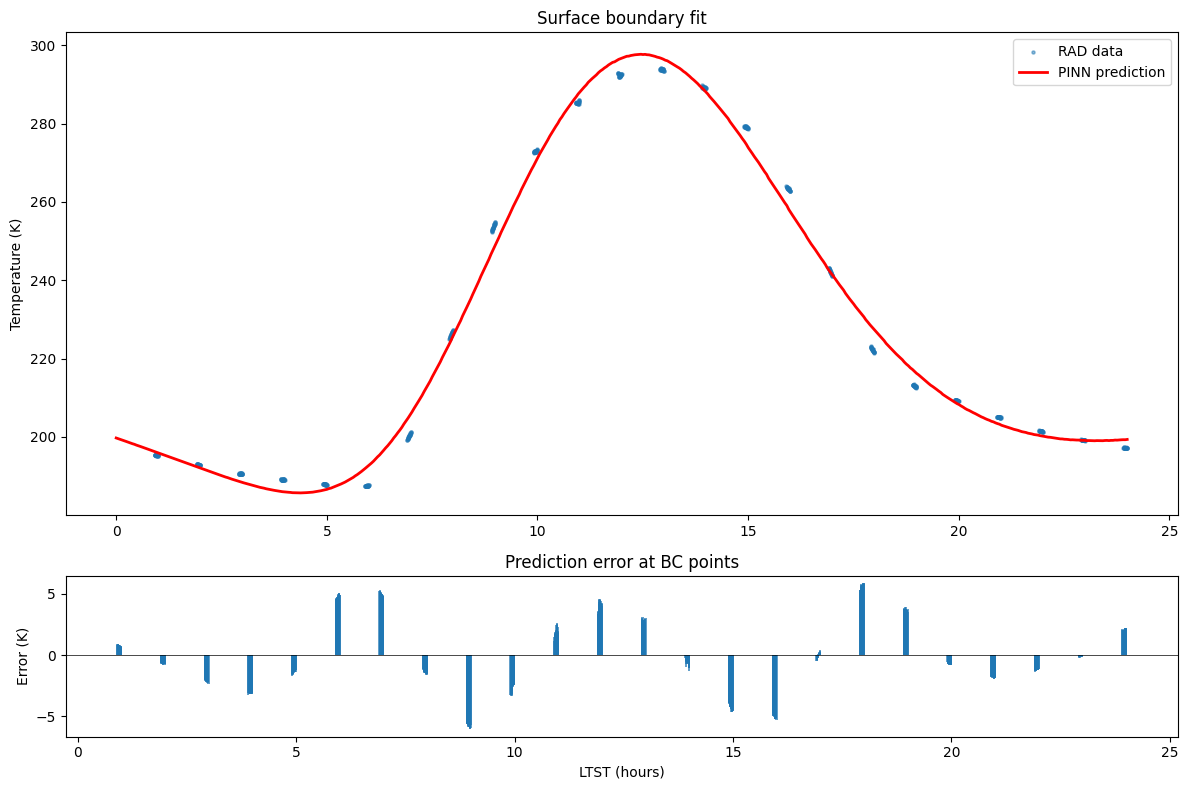

In [27]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]})

# Predicted surface temperature on a fine grid
t_plot = jnp.linspace(0, 1, 500).reshape(-1, 1)
x_surface = jnp.zeros_like(t_plot)
tx_surface = jnp.concatenate([t_plot, x_surface], axis=1)
T_pred_surface = unnormalize_u(network(params, tx_surface)).ravel()

hours_plot = t_plot.ravel() * 24

# Top: overlay
axes[0].scatter(jnp.array(ltst_surf) / sol_seconds * 24, temp_surf,
                s=5, alpha=0.5, label='RAD data')
axes[0].plot(hours_plot, T_pred_surface, 'r', linewidth=2, label='PINN prediction')
axes[0].set_ylabel('Temperature (K)')
axes[0].legend()
axes[0].set_title('Surface boundary fit')

# Bottom: error at actual BC points
# First n_surface entries of t_bc, x_bc are the surface points
tx_bc_surf = jnp.concatenate([t_bc[:n_surface], x_bc[:n_surface]], axis=1)
T_pred_at_data = unnormalize_u(network(params, tx_bc_surf)).ravel()
T_true = jnp.array(temp_surf)
error = T_pred_at_data - T_true

hours_data = jnp.array(ltst_surf) / sol_seconds * 24
axes[1].bar(hours_data, error, width=0.05, alpha=0.7)
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].set_ylabel('Error (K)')
axes[1].set_xlabel('LTST (hours)')
axes[1].set_title('Prediction error at BC points')

plt.tight_layout()
plt.show()